In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import scipy as sp
import cartopy.crs as ccrs
from numba import njit, prange
from tqdm import tqdm
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import jensenshannon

## Task 1

In [2]:
df = pd.read_csv('sdss_cutout.csv')

We select subsample with redshifts 0.09 < z < 0.1

In [3]:
data_cut = df[(df['Z'] > 0.09) & (df['Z'] < 0.1)].copy()

In [4]:
data_cut['u-r'] = data_cut['phot_u'] - data_cut['phot_r']

In [5]:
red = data_cut[data_cut['u-r'] > 2.3]
blue = data_cut[data_cut['u-r'] <= 2.3]

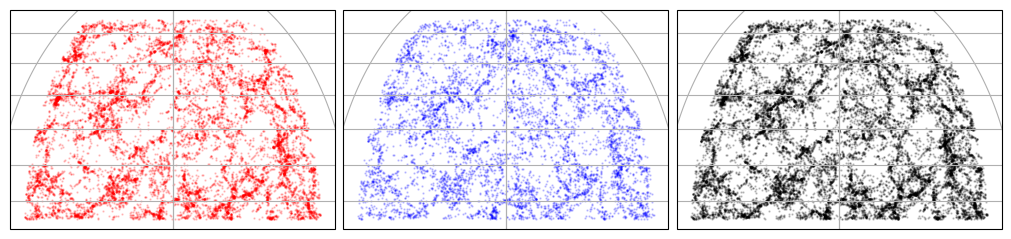

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(10, 15), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax[0].gridlines()
ax[0].scatter(red['RA'], red['DEC'], s=0.5, alpha=0.2, transform=ccrs.PlateCarree(), color='red')

ax[1].gridlines()
ax[1].scatter(blue['RA'], blue['DEC'], s=0.5, alpha=0.2, transform=ccrs.PlateCarree(), color='blue')

ax[2].gridlines()
ax[2].scatter(data_cut['RA'], data_cut['DEC'], s=0.5, alpha=0.2, transform=ccrs.PlateCarree(), color='black')


## Task 2

In [7]:
# transform pandas DataFrame into numpy array of coordinates
cut_np = np.array([data_cut['RA'].values, data_cut['DEC'].values]).T

We use different methods to estimate the optimal bandwidth for the KDE

First, we try k-fold method, because it is faster.

In [8]:
bandwidths = np.geomspace(0.05, 15.0, 30)
grid2 = GridSearchCV(KernelDensity(kernel='gaussian'),
{'bandwidth': bandwidths}, cv=5, n_jobs=-1)
grid2.fit(cut_np)
h_opt_kfold = grid2.best_params_['bandwidth']
h_opt_kfold

np.float64(12.321775300660944)

In [38]:
bandwidths = np.geomspace(0.05, 15.0, 30)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
{'bandwidth': bandwidths}, cv=LeaveOneOut(), n_jobs=-1)
grid.fit(cut_np)
h_opt = grid.best_params_['bandwidth']
h_opt

np.float64(0.2935835874478196)

Text(0.5, 1.0, 'k-fold')

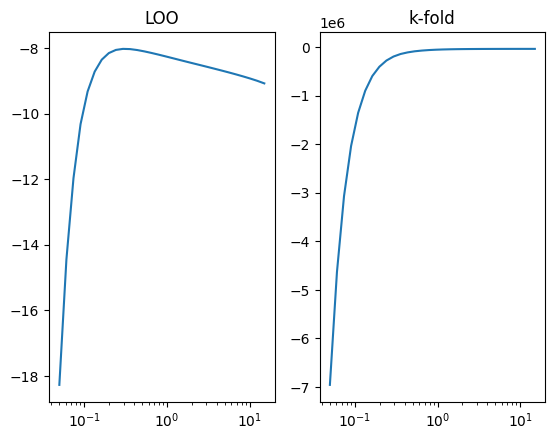

In [39]:
fig, ax = plt.subplots(1, 2)
ax[0].plot(bandwidths, grid.cv_results_['mean_test_score'])
ax[0].set_xscale('log')
ax[0].set_title('LOO')
ax[1].plot(bandwidths, grid2.cv_results_['mean_test_score'])
ax[1].set_xscale('log')
ax[1].set_title('k-fold')

In [40]:
def uniform_grid(data, n=(1000, 1000)):
    x_min, y_min = np.min(data, axis=0)
    x_max, y_max = np.max(data, axis=0)

    x_sample = np.linspace(x_min, x_max, n[0])
    y_sample = np.linspace(y_min, y_max, n[1])

    res = np.meshgrid(x_sample, y_sample)
    return res

In [41]:
X, Y = uniform_grid(cut_np, (300, 300))

In [42]:
xy = np.vstack([X.ravel(), Y.ravel()]).T

In [44]:
kde_loo = KernelDensity(kernel='gaussian', bandwidth=h_opt).fit(cut_np)

density_map_log = kde_loo.score_samples(xy).reshape(X.shape)
density_map = np.exp(kde_loo.score_samples(xy)).reshape(X.shape)

In [45]:
kde2 = KernelDensity(kernel='gaussian', bandwidth='silverman').fit(cut_np)

density_map2_log =kde2.score_samples(xy).reshape(X.shape)
density_map2 = np.exp(kde2.score_samples(xy)).reshape(X.shape)

In [47]:
kde3 = KernelDensity(kernel='gaussian', bandwidth=h_opt_kfold).fit(cut_np)

density_map3_log =kde3.score_samples(xy).reshape(X.shape)
density_map3 = np.exp(kde3.score_samples(xy)).reshape(X.shape)

In [48]:
def silvermans_h(sample):
    std_x = np.std(sample[:,0])
    std_y = np.std(sample[:,1])
    std_xy = np.sqrt(std_x**2 + std_y**2)
    return 1.06*std_xy*float(len(sample))**(-1./5.)

In [49]:
h_sil = silvermans_h(cut_np)

In [50]:
kde4 = KernelDensity(kernel='gaussian', bandwidth=h_sil).fit(cut_np)

density_map4_log =kde4.score_samples(xy).reshape(X.shape)
density_map4 = np.exp(kde4.score_samples(xy)).reshape(X.shape)

Text(0.5, 1.0, "Silverman's analytical")

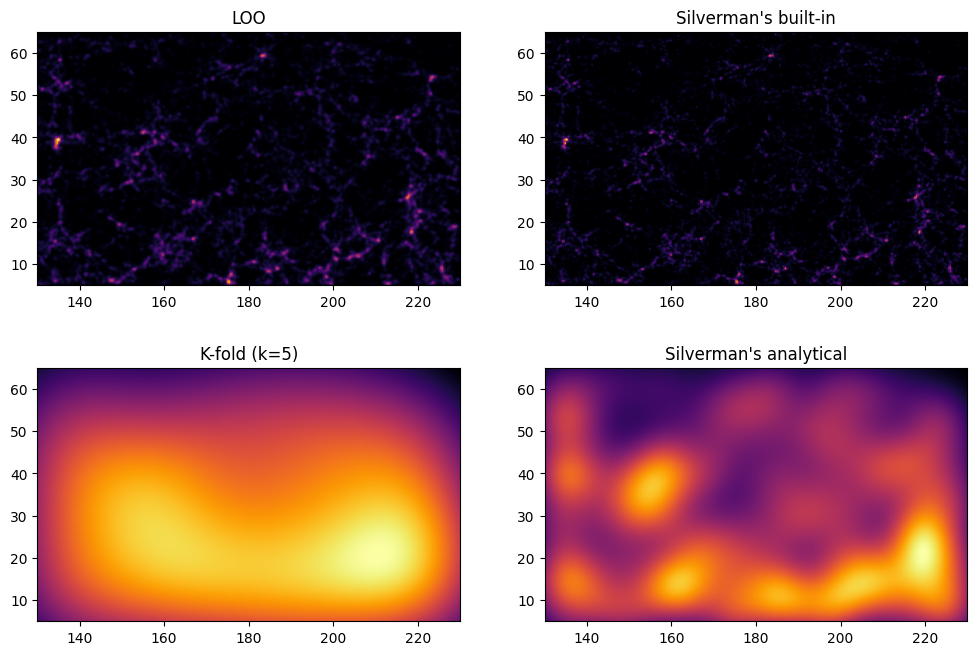

In [51]:
figure, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
ax[0].imshow(density_map, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='inferno')
# ax[0].scatter(cut_np[:,0], cut_np[:,1], s=0.2, alpha=0.8, color='red')
ax[0].set_title('LOO')
ax[1].imshow(density_map2, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='inferno')
# ax[1].scatter(cut_np[:,0], cut_np[:,1], s=0.2, alpha=0.8, color='red')
ax[1].set_title("Silverman's built-in")
ax[2].imshow(density_map3, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='inferno')
# ax[1].scatter(cut_np[:,0], cut_np[:,1], s=0.2, alpha=0.8, color='red')
ax[2].set_title('K-fold (k=5)')
ax[3].imshow(density_map4, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='inferno')
# ax[1].scatter(cut_np[:,0], cut_np[:,1], s=0.2, alpha=0.8, color='red')
ax[3].set_title("Silverman's analytical")

In [53]:
kde_oversmoothed = KernelDensity(kernel='gaussian', bandwidth=h_opt*5.).fit(cut_np)

logdens_map_os = kde_oversmoothed.score_samples(xy).reshape(X.shape)
density_map_os = np.exp(logdens_map_os)

In [54]:
kde_undersmoothed = KernelDensity(kernel='gaussian', bandwidth=h_opt/5.).fit(cut_np)

logdens_map_us = kde_undersmoothed.score_samples(xy).reshape(X.shape)
density_map_us = np.exp(logdens_map_us)

Text(0.5, 1.0, 'Oversmoothed')

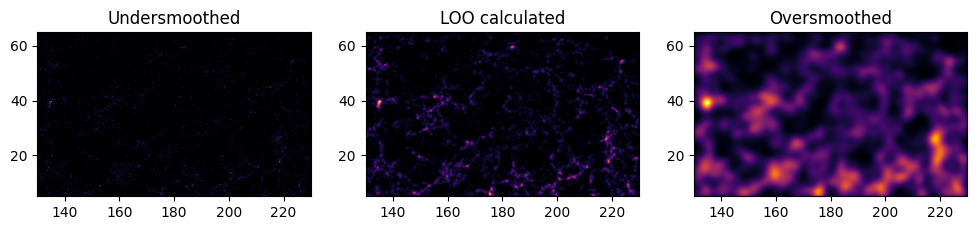

In [71]:
figure, ax = plt.subplots(1, 3, figsize=(12, 4))
ax = ax.flatten()
ax[0].imshow(density_map_us, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='inferno')
# ax[0].scatter(cut_np[:,0], cut_np[:,1], s=0.2, alpha=0.8, color='red')
ax[0].set_title('Undersmoothed')
ax[1].imshow(density_map, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='inferno')
# ax[1].scatter(cut_np[:,0], cut_np[:,1], s=0.2, alpha=0.8, color='red')
ax[1].set_title("LOO calculated")
ax[2].imshow(density_map_os, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='inferno')
# ax[1].scatter(cut_np[:,0], cut_np[:,1], s=0.2, alpha=0.8, color='red')
ax[2].set_title('Oversmoothed')

## Task 3

In [56]:
colors = data_cut['u-r'].values[:,np.newaxis]

In [57]:
bic_scores=[]
models = dict()
for k in range(1,7):
    gm=GaussianMixture(n_components=k, n_init=5).fit(colors)
    bic_scores.append(gm.bic(colors))
    models[k] = gm
    print(bic_scores)

[28772.74739379547]
[28772.74739379547, 24630.23303740432]
[28772.74739379547, 24630.23303740432, 24723.56622567359]
[28772.74739379547, 24630.23303740432, 24723.56622567359, 23069.971849454116]
[28772.74739379547, 24630.23303740432, 24723.56622567359, 23069.971849454116, 22694.90593840573]
[28772.74739379547, 24630.23303740432, 24723.56622567359, 23069.971849454116, 22694.90593840573, 22647.032060395064]


Text(0.5, 1.0, 'BIC Score for Each Gaussian Mixture Model')

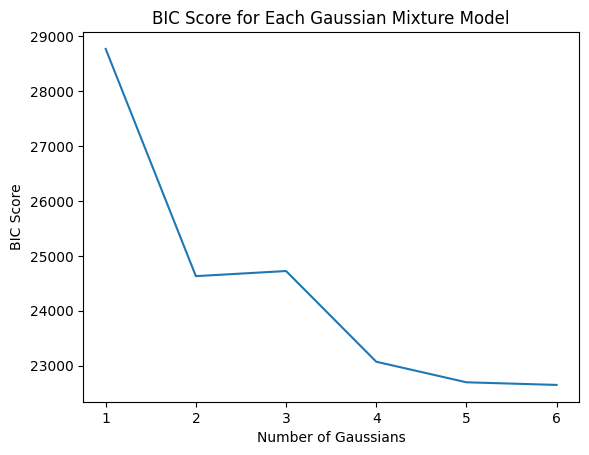

In [58]:
plt.plot(range(1,7), bic_scores)
plt.xlabel('Number of Gaussians')
plt.ylabel('BIC Score')
plt.title('BIC Score for Each Gaussian Mixture Model')

[577064.1629687388]
[577064.1629687388, 561803.715588916]
[577064.1629687388, 561803.715588916, 545891.2863811177]
[577064.1629687388, 561803.715588916, 545891.2863811177, 545407.205852693]
[577064.1629687388, 561803.715588916, 545891.2863811177, 545407.205852693, 544837.5461435679]
[577064.1629687388, 561803.715588916, 545891.2863811177, 545407.205852693, 544837.5461435679, 543475.0390877989]


Text(0.5, 1.0, 'BIC Score for Each Gaussian Mixture Model')

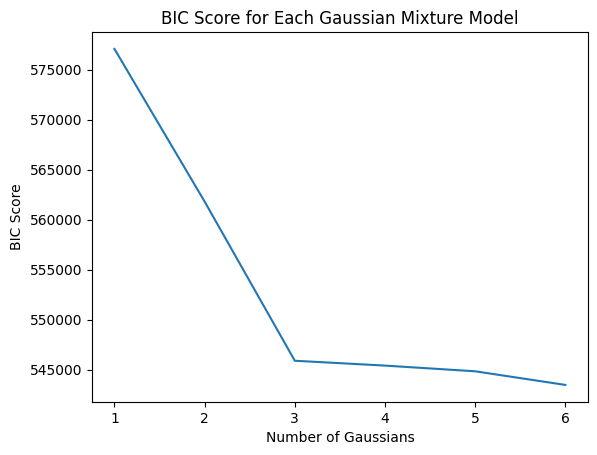

In [59]:
df['u-r'] = df['phot_u'] - df['phot_r']

colors_full_sample = df['u-r'].values[:, np.newaxis]
bic_scores_full_sample = []
models_full_sample = dict()
for k in range(1, 7):
    gm = GaussianMixture(n_components=k, n_init=5).fit(colors_full_sample)
    bic_scores_full_sample.append(gm.bic(colors_full_sample))
    models_full_sample[k] = gm
    print(bic_scores_full_sample)
plt.plot(range(1, 7), bic_scores_full_sample)
plt.xlabel('Number of Gaussians')
plt.ylabel('BIC Score')
plt.title('BIC Score for Each Gaussian Mixture Model')

(array([1.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 5.000e+00, 9.000e+00,
        1.000e+01, 2.900e+01, 3.900e+01, 4.800e+01, 7.400e+01, 1.260e+02,
        1.370e+02, 1.700e+02, 2.260e+02, 2.550e+02, 3.290e+02, 4.150e+02,
        4.230e+02, 4.280e+02, 4.940e+02, 5.060e+02, 5.030e+02, 4.810e+02,
        4.980e+02, 4.670e+02, 4.620e+02, 4.460e+02, 4.270e+02, 4.470e+02,
        4.500e+02, 4.340e+02, 4.680e+02, 4.830e+02, 5.660e+02, 6.830e+02,
        7.360e+02, 9.250e+02, 1.109e+03, 1.319e+03, 1.382e+03, 1.256e+03,
        1.036e+03, 7.390e+02, 4.770e+02, 2.500e+02, 1.480e+02, 9.000e+01,
        4.700e+01, 3.600e+01, 2.100e+01, 1.400e+01, 1.600e+01, 1.600e+01,
        6.000e+00, 7.000e+00, 5.000e+00, 5.000e+00, 0.000e+00, 2.000e+00,
        1.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+0

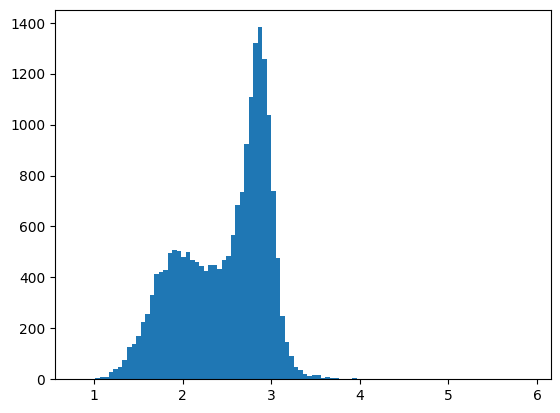

In [60]:
plt.hist(colors, bins=100)

[4142.5143563911515, -93.33318826926916, 1653.594376219473, 375.0659110483866, 47.87387801066507]


Text(0.5, 1.0, 'Difference in BIC scores')

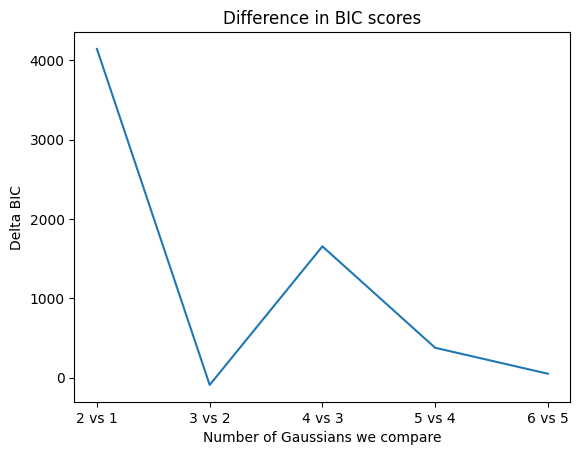

In [61]:
delta_bic = []
for k in range(1, 6):
    delta_bic.append(bic_scores[k - 1] - bic_scores[k])
print(delta_bic)

plt.plot(range(2, 7), delta_bic)
labels = [f'{x} vs {x-1}' for x in range(2, 7)]
plt.xticks(range(2, 7), labels=labels)
plt.xlabel('Number of Gaussians we compare')
plt.ylabel('Delta BIC')
plt.title('Difference in BIC scores')

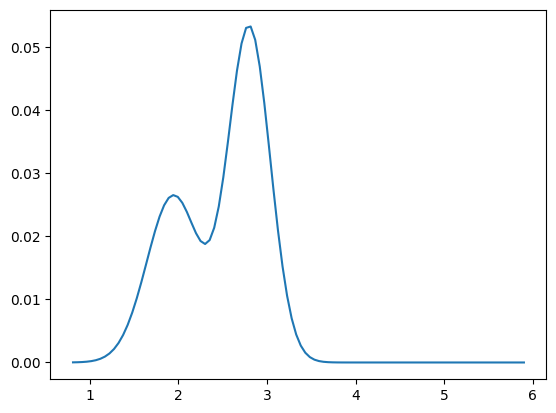

In [62]:
x = np.linspace(colors.min(), colors.max(), 100).reshape(-1, 1)
# 'models' is a dict, where keys are the number of gaussians in the model
log_probs = models[2].score_samples(x)
sum_of_scores = (np.exp(log_probs)).sum()
probs = np.exp(log_probs) / sum_of_scores
plt.plot(x, probs)

In [63]:
tau = models[2].predict_proba(colors)
means = models[2].means_.ravel()
# red galaxies have higher u-r color
red = np.argmax(means)
# blue galaxies have lower u-r color
blue = np.argmin(means)
tau_red = tau[:, red]
tau_blue = tau[:, blue]
print(means)
print(red)
print(blue)

[2.80003768 1.94315261]
0
1


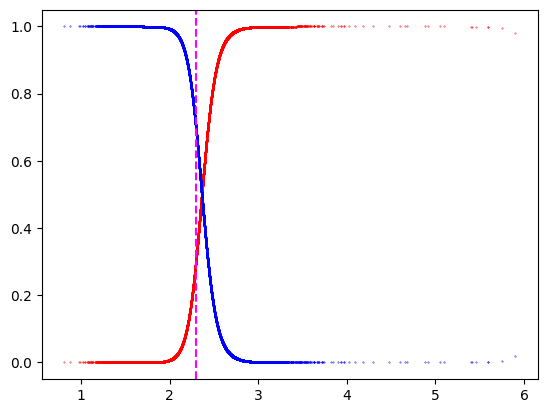

In [64]:
plt.scatter(colors, tau_red, s=0.1, color = 'r')
plt.scatter(colors, tau_blue, s=0.1, color='b')
plt.axvline(2.3, color = 'magenta', ls='--')

# Task 4

In [65]:
# kde_opt = KernelDensity(kernel='gaussian', bandwidth=h_opt).fit(cut_np)
rho = np.exp(kde_loo.score_samples(cut_np))

In [66]:
q25 = np.quantile(rho,0.25)
q75 = np.quantile(rho, 0.75)

high_dens = (rho >= q75)
low_dens =  (rho <= q25)

c_high = colors[high_dens]
c_low = colors[low_dens]

In [67]:
kde_low=KernelDensity(kernel='gaussian', bandwidth='silverman').fit(c_low)
kde_high=KernelDensity(kernel='gaussian', bandwidth='silverman').fit(c_high)


cgrid=np.linspace(colors.min(),colors.max(), 500)
p_low =np.exp(kde_low.score_samples(cgrid[:,np.newaxis]))
p_high=np.exp(kde_high.score_samples(cgrid[:,np.newaxis]))
dc= cgrid[1]-cgrid[0]
p_low /=p_low.sum()*dc; p_high /=p_high.sum()*dc
D_JS = jensenshannon(p_low,p_high)**2 #returnssqrt(D_JS),sosquareit


Text(0.5, 1.0, 'KDE of Galaxy Colors by Luminosity')

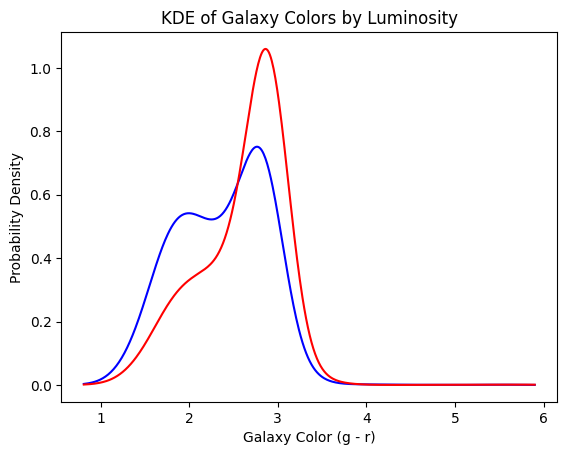

In [68]:
plt.figure()
plt.plot(cgrid, p_low, color = 'b')
plt.plot(cgrid, p_high, color = 'r')
plt.xlabel('Galaxy Color (g - r)')
plt.ylabel('Probability Density')
plt.title(r'KDE of Galaxy Colors by Luminosity')

## Task 5

In [69]:
rho = np.log(rho)

color = colors.flatten()
red_col = (color > 2.3)
blue_col = (color <= 2.3)

red_vals=rho[red_col]
blue_vals=rho[blue_col]

blue_data = blue_vals[:, np.newaxis]
red_data = red_vals [:, np.newaxis]


kde_blue=KernelDensity(kernel='gaussian', bandwidth='silverman').fit(blue_data)
kde_red=KernelDensity(kernel='gaussian', bandwidth='silverman').fit(red_data)

lmin=min(red_vals.min(), blue_vals.min())
lmax=max(red_vals.max(), blue_vals.max())
lgrid=np.linspace(lmin, lmax, 500)
dl=lgrid[1]-lgrid[0]

p_blue=np.exp(kde_blue.score_samples(lgrid[:, np.newaxis]))
p_red=np.exp(kde_red.score_samples(lgrid[:, np.newaxis]))

p_blue/=p_blue.sum() * dl; p_red  /= p_red.sum() * dl

D_JSrb=jensenshannon(p_blue,p_red)**2

Text(0.5, 1.0, 'KDE of Local Density by Galaxy Color')

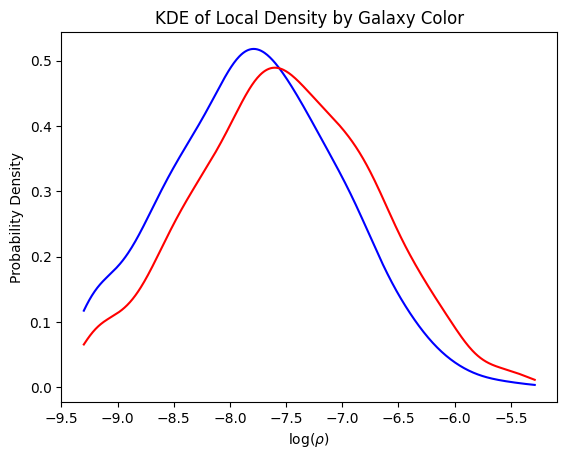

In [70]:
plt.plot(lgrid, p_blue, color = 'b')
plt.plot(lgrid, p_red, color = 'r')
plt.xlabel(r'$\log(\rho)$')
plt.ylabel('Probability Density')
plt.title('KDE of Local Density by Galaxy Color')